<a href="https://colab.research.google.com/github/nesbita/ML-Collision-Severity-YOLO-Detection/blob/main/Ariana_Nesbit_Ass1_T13.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import pickle
from sklearn.model_selection import StratifiedKFold
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import roc_auc_score, average_precision_score, RocCurveDisplay, PrecisionRecallDisplay
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import precision_recall_curve
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from google.colab import drive

In [ ]:
drive.mount('/content/drive')

# load T1.1 notebook
SAVE_PATH = '/content/drive/MyDrive/Colab Notebooks/'

df = pd.read_csv(SAVE_PATH + 'df_clean.csv')

with open(SAVE_PATH + 'feature_config.pkl', 'rb') as f:
    feature_config = pickle.load(f)

with open(SAVE_PATH + 'preprocessor.pkl', 'rb') as f:
    preprocessor = pickle.load(f)

print('loaded')


# collision_severity - Three-class classification: Slight vs Serious vs Fatal
# 0 = slight, 1 = serious, 2 = fatal

# reassigned values
df['collision_severity'] = df['collision_severity'].map({3: 0, 2: 1, 1: 1})
print(df['collision_severity'].value_counts().sort_index())

# separate features x and target y
X = df.drop(columns='collision_severity')
y = df['collision_severity']

print('X shape:', X.shape)
print('y shape:', y.shape)


## K-FOLD CROSS-VALIDATION & MODEL PERFORMANCE

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


Mounted at /content/drive
loaded
collision_severity
0    75858
1    25069
Name: count, dtype: int64
X shape: (100927, 18)
y shape: (100927,)


In [ ]:
# split training and validation folds so they're balanced

baseline_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    print(f'Fold {fold + 1}: train size = {len(X_train)}, val size = {len(X_val)}')

    # preprocessing training data
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)

    ## majority-class baseline
    model = DummyClassifier(strategy='most_frequent')
    model.fit(X_train_proc, y_train)

    # prediction
    y_pred = model.predict(X_val_proc)

    # calculate metrics
    results = {
        'fold': fold + 1,
        'accuracy': accuracy_score(y_val, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_val, y_pred),
        'macro_f1': f1_score(y_val, y_pred, average='macro'),
        'auroc': roc_auc_score(y_val, y_pred),
        'auprc': average_precision_score(y_val, y_pred),
    }
    baseline_results.append(results)
    print(f'Fold {fold + 1} done.')

print('Baseline complete.')

results_df = pd.DataFrame(baseline_results)
print(results_df)
print()
print('Mean scores:')
print(results_df[['accuracy', 'balanced_accuracy', 'macro_f1', 'auroc', 'auprc']].mean())

# get predictions for last fold for illustration
print('Classification Report (last fold):')
print(classification_report(y_val, y_pred, target_names=['Slight', 'Serious/Fatal'], zero_division=0))

print('Confusion Matrix (last fold):')
print(confusion_matrix(y_val, y_pred))

Fold 1: train size = 80741, val size = 20186
Fold 1 done.
Fold 2: train size = 80741, val size = 20186
Fold 2 done.
Fold 3: train size = 80742, val size = 20185
Fold 3 done.
Fold 4: train size = 80742, val size = 20185
Fold 4 done.
Fold 5: train size = 80742, val size = 20185
Fold 5 done.
Baseline complete.
   fold  accuracy  balanced_accuracy  macro_f1  auroc     auprc
0     1  0.751610                0.5  0.429097    0.5  0.248390
1     2  0.751610                0.5  0.429097    0.5  0.248390
2     3  0.751647                0.5  0.429109    0.5  0.248353
3     4  0.751598                0.5  0.429093    0.5  0.248402
4     5  0.751598                0.5  0.429093    0.5  0.248402

Mean scores:
accuracy             0.751613
balanced_accuracy    0.500000
macro_f1             0.429097
auroc                0.500000
auprc                0.248387
dtype: float64
Classification Report (last fold):
               precision    recall  f1-score   support

       Slight       0.75      1.00   

In [ ]:
## multinomial logical regression model

lr_results = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # preprocessing training data
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)

    # logistic regression
    model = LogisticRegression(max_iter=1000,
                           class_weight='balanced',
                           random_state=42)

    # fit model
    model.fit(X_train_proc, y_train)

    # predictions
    y_pred = model.predict(X_val_proc)
    y_pred_proba = model.predict_proba(X_val_proc)[:, 1]

    # calculate metrics
    results = {
        'fold': fold + 1,
        'accuracy': accuracy_score(y_val, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_val, y_pred),
        'macro_f1': f1_score(y_val, y_pred, average='macro'),
        'auroc': roc_auc_score(y_val, y_pred_proba),
        'auprc': average_precision_score(y_val, y_pred_proba),
    }
    lr_results.append(results)
    print(f'Fold {fold + 1} done.')

print('Logistic Regression complete.')

results_df = pd.DataFrame(lr_results)
print(results_df)
print()
print('Mean scores:')
print(results_df[['accuracy', 'balanced_accuracy', 'macro_f1','auroc', 'auprc']].mean())

print('\nClassification Report (last fold):')
print(classification_report(y_val, y_pred,
      target_names=['Slight', 'Serious/Fatal'],
      zero_division=0))

print('Confusion Matrix (last fold):')
print(confusion_matrix(y_val, y_pred))

Fold 1 done.
Fold 2 done.
Fold 3 done.
Fold 4 done.
Fold 5 done.
Logistic Regression complete.
   fold  accuracy  balanced_accuracy  macro_f1     auroc     auprc
0     1  0.585604           0.568297  0.538207  0.586846  0.327668
1     2  0.588576           0.576617  0.543597  0.597397  0.338361
2     3  0.590389           0.569978  0.541204  0.589688  0.323131
3     4  0.584642           0.570529  0.538845  0.592015  0.328662
4     5  0.596928           0.577901  0.548134  0.596244  0.334286

Mean scores:
accuracy             0.589228
balanced_accuracy    0.572664
macro_f1             0.541997
auroc                0.592438
auprc                0.330421
dtype: float64

Classification Report (last fold):
               precision    recall  f1-score   support

       Slight       0.80      0.62      0.70     15171
Serious/Fatal       0.32      0.54      0.40      5014

     accuracy                           0.60     20185
    macro avg       0.56      0.58      0.55     20185
 weighted a

In [ ]:
## DNN using TensorFlow

# calculating class weights
classes = np.unique(y)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y)
class_weight_dict = dict(zip(classes, weights))
print('Class weights:', class_weight_dict)

def build_model(input_dim):
    model = keras.Sequential([
        keras.Input(shape=(input_dim,)),
        layers.Dense(128, activation='relu'), #hidden 1
        layers.Dropout(0.3), # prevents overfitting during training
        layers.Dense(64, activation='relu'), # hidden 2
        layers.Dropout(0.3), # output
        layers.Dense(1, activation='sigmoid') # 1 neurons for 1 class
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    return model


dnn_results = []
fold_histories = [] #training history of folds

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

    # preprocessing
    X_train_proc = preprocessor.fit_transform(X_train)
    X_val_proc = preprocessor.transform(X_val)

    # build and train model
    model = build_model(X_train_proc.shape[1]) # new model for each fold

    history = model.fit(        #trainer
        X_train_proc, y_train,
        validation_data=(X_val_proc, y_val),  # evaluate after each epoch
        epochs=20,
        batch_size=256,
        class_weight=class_weight_dict,  # makes fatal cases more important
        verbose=0
    )

    fold_histories.append(history)

    # predictions
    y_pred_proba = model.predict(X_val_proc).flatten()
    y_pred = (y_pred_proba >= 0.5).astype(int)

    results = {
        'fold': fold + 1,
        'accuracy': accuracy_score(y_val, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_val, y_pred),
        'macro_f1': f1_score(y_val, y_pred, average='macro'),
        'auroc': roc_auc_score(y_val, y_pred_proba),
        'auprc': average_precision_score(y_val, y_pred_proba),
    }
    dnn_results.append(results)
    print(f'Fold {fold + 1} done.')

print('DNN complete.')

results_df = pd.DataFrame(dnn_results)
print(results_df)
print()
print('Mean scores:')
print(results_df[['accuracy', 'balanced_accuracy', 'macro_f1']].mean())

print('\nClassification Report (last fold):')
print(classification_report(y_val, y_pred,
      target_names=['Slight', 'Serious/Fatal'],
      zero_division=0))

print('Confusion Matrix (last fold):')
print(confusion_matrix(y_val, y_pred))


Class weights: {np.int64(0): np.float64(0.6652363626776345), np.int64(1): np.float64(2.0129841637081656)}
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step
Fold 1 done.
631/631 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step
Fold 2 done.
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Fold 3 done.
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Fold 4 done.
631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Fold 5 done.
DNN complete.
   fold  accuracy  balanced_accuracy  macro_f1     auroc     auprc
0     1  0.633261           0.572092  0.559397  0.605660  0.346016
1     2  0.604181           0.580255  0.552601  0.614074  0.347778
2     3  0.632103           0.573684  0.560002  0.608960  0.337072
3     4  0.616052           0.576335  0.555556  0.607721  0.342342
4     5  0.574288           0.575458  0.536004  0.609520  0.345326

Mean scores:
accuracy             0.611977
balanced_accuracy    0.575565
macro_f1             0.552712
dtype: float64

Classification Report (last fold):
               precision    recall  f1-score   suppor

In [ ]:
## Summary table with Accuracy, Balanced Accuracy, Macry F1, AUROC, & AUPRC

summary = pd.DataFrame({
    'Model': ['Majority Baseline', 'Logistic Regression', 'DNN'],
    'Accuracy': [
        pd.DataFrame(baseline_results)['accuracy'].mean(),
        pd.DataFrame(lr_results)['accuracy'].mean(),
        pd.DataFrame(dnn_results)['accuracy'].mean(),
    ],
    'Balanced Accuracy': [
        pd.DataFrame(baseline_results)['balanced_accuracy'].mean(),
        pd.DataFrame(lr_results)['balanced_accuracy'].mean(),
        pd.DataFrame(dnn_results)['balanced_accuracy'].mean(),
    ],
    'Macro F1': [
        pd.DataFrame(baseline_results)['macro_f1'].mean(),
        pd.DataFrame(lr_results)['macro_f1'].mean(),
        pd.DataFrame(dnn_results)['macro_f1'].mean(),
    ],
    'AUROC': [
        pd.DataFrame(baseline_results)['auroc'].mean(),
        pd.DataFrame(lr_results)['auroc'].mean(),
        pd.DataFrame(dnn_results)['auroc'].mean(),
    ],
    'AUPRC': [
        pd.DataFrame(baseline_results)['auprc'].mean(),
        pd.DataFrame(lr_results)['auprc'].mean(),
        pd.DataFrame(dnn_results)['auprc'].mean(),
    ],
})

summary = summary.round(4)
summary

,Model,Accuracy,Balanced Accuracy,Macro F1,AUROC,AUPRC
0,Majority Baseline,0.7516,0.5000,0.4291,0.5000,0.2484
1,Logistic Regression,0.5892,0.5727,0.5420,0.5924,0.3304
2,DNN,0.6120,0.5756,0.5527,0.6092,0.3437


In [ ]:
## Summary table with F1-score & Confusion Matrices

# re-run last fold predictions for all models
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc = preprocessor.transform(X_val)

# baseline
model_b = DummyClassifier(strategy='most_frequent')
model_b.fit(X_train_proc, y_train)
y_pred_baseline = model_b.predict(X_val_proc)

# logistic regression
model_lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model_lr.fit(X_train_proc, y_train)
y_pred_lr_last = model_lr.predict(X_val_proc)

# DNN
model_dnn = build_model(X_train_proc.shape[1])
model_dnn.fit(X_train_proc, y_train, epochs=20, batch_size=256,
              class_weight=class_weight_dict, verbose=0)
y_pred_dnn_last = (model_dnn.predict(X_val_proc).flatten() >= 0.5).astype(int)

# print reports
for name, y_pred_last in [('MAJORITY BASELINE', y_pred_baseline),
                           ('LOGISTIC REGRESSION', y_pred_lr_last),
                           ('DNN', y_pred_dnn_last)]:
    print('=' * 60)
    print(name)
    print(classification_report(y_val, y_pred_last,
          target_names=['Slight', 'Serious/Fatal'], zero_division=0))
    print('Confusion Matrix:')
    print(confusion_matrix(y_val, y_pred_last))

print('=' * 60)

631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
MAJORITY BASELINE
               precision    recall  f1-score   support

       Slight       0.75      1.00      0.86     15171
Serious/Fatal       0.00      0.00      0.00      5014

     accuracy                           0.75     20185
    macro avg       0.38      0.50      0.43     20185
 weighted avg       0.56      0.75      0.65     20185

Confusion Matrix:
[[15171     0]
 [ 5014     0]]
LOGISTIC REGRESSION
               precision    recall  f1-score   support

       Slight       0.80      0.62      0.70     15171
Serious/Fatal       0.32      0.54      0.40      5014

     accuracy                           0.60     20185
    macro avg       0.56      0.58      0.55     20185
 weighted avg       0.68      0.60      0.62     20185

Confusion Matrix:
[[9341 5830]
 [2306 2708]]
DNN
               precision    recall  f1-score   support

       Slight       0.81      0.61      0.69     15171
Serious/Fatal       0.32      0.56      0.41  

631/631 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


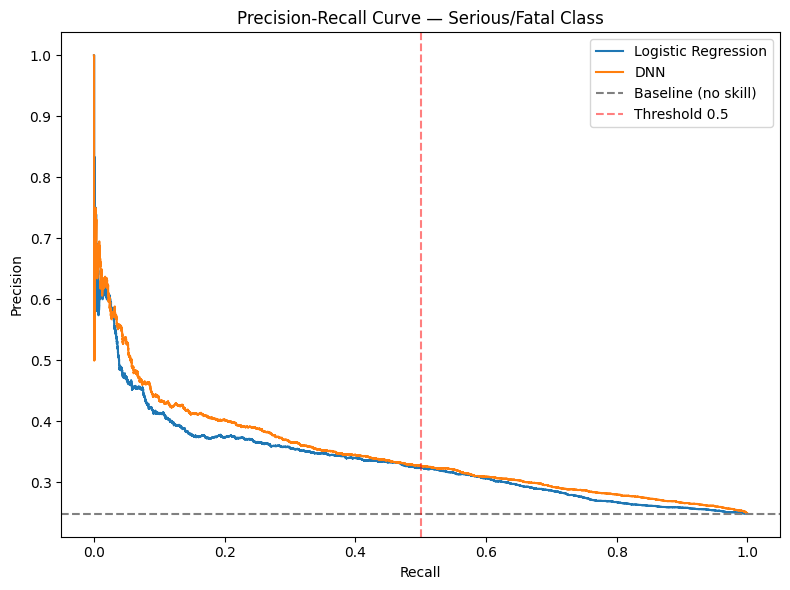

In [ ]:
## Precision recall curve


# get probability predictions for last fold
y_proba_lr = model_lr.predict_proba(X_val_proc)[:, 1]
y_proba_dnn = model_dnn.predict(X_val_proc).flatten()

# calculate precision-recall curves
precision_lr, recall_lr, thresholds_lr = precision_recall_curve(y_val, y_proba_lr)
precision_dnn, recall_dnn, thresholds_dnn = precision_recall_curve(y_val, y_proba_dnn)

# plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(recall_lr, precision_lr, label='Logistic Regression')
ax.plot(recall_dnn, precision_dnn, label='DNN')
ax.axhline(y=0.248, color='grey', linestyle='--', label='Baseline (no skill)')
ax.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Threshold 0.5')

ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
ax.set_title('Precision-Recall Curve — Serious/Fatal Class')
ax.legend()

plt.tight_layout()
plt.savefig(SAVE_PATH + 'precision_recall_curve.png', dpi=150)
plt.show()

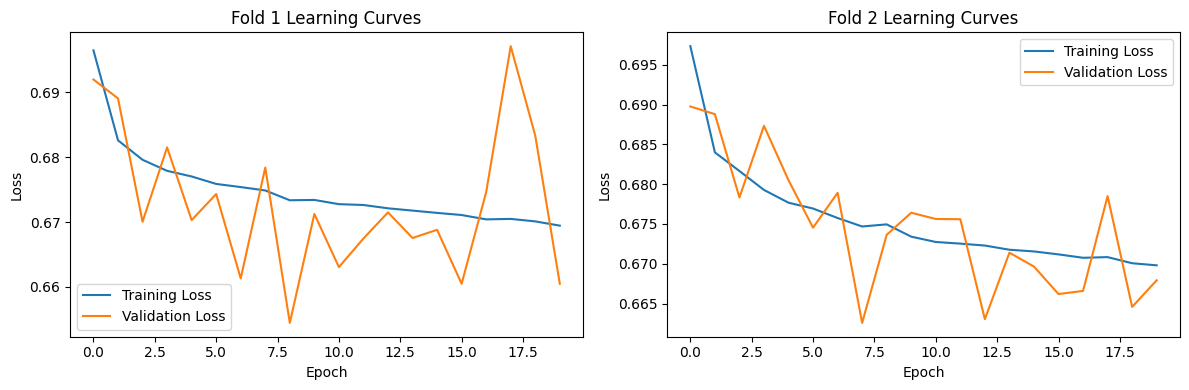

In [ ]:
## plot the training and validation loss curves (DNN)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for fold_idx in [0, 1]:
    history = fold_histories[fold_idx]
    axes[fold_idx].plot(history.history['loss'], label='Training Loss')
    axes[fold_idx].plot(history.history['val_loss'], label='Validation Loss')
    axes[fold_idx].set_title(f'Fold {fold_idx + 1} Learning Curves')
    axes[fold_idx].set_xlabel('Epoch')
    axes[fold_idx].set_ylabel('Loss')
    axes[fold_idx].legend()

plt.tight_layout()
plt.savefig(SAVE_PATH + 'dnn_learning_curves_t13.png', dpi=150)
plt.show()